In [4]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
df = pd.read_csv('D:\Projects\decodelabs projects\project 4\data\IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
df.info()

df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [9]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [10]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [12]:
import nltk

# Ensure the tokenizer resources exist before preprocessing
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

df['clean_review'] = df['review'].apply(preprocess)

In [13]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print(classification_report(y_test, y_pred))

Accuracy : 0.8556
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4961
           1       0.85      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



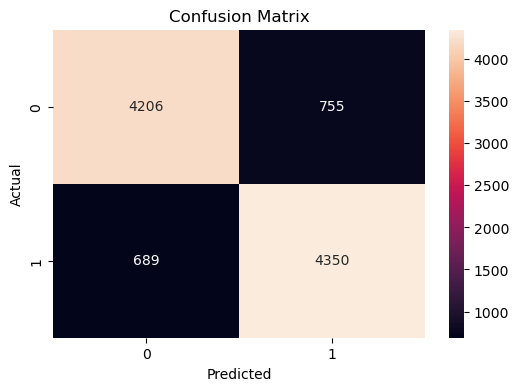

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/sentiment_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']

In [21]:
sample = [
    "This movie is amazing and wonderful"
]

sample_clean = [preprocess(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


Note: you may need to restart the kernel to use updated packages.


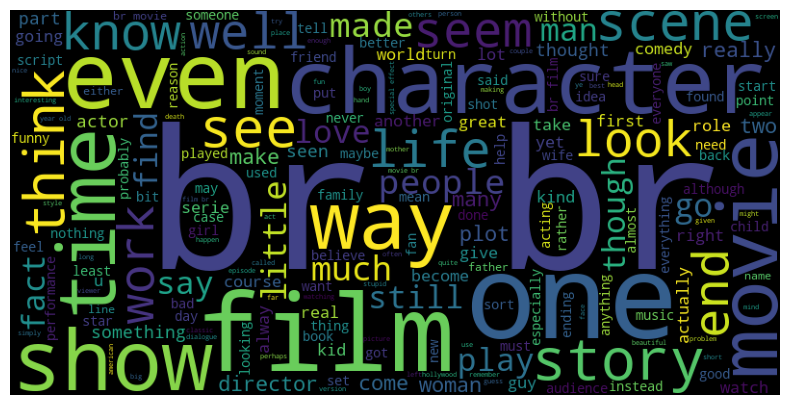

In [24]:
%pip install wordcloud
from wordcloud import WordCloud

text = " ".join(df['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()